The mathematical building blocks of neural networks

In [2]:
import keras
from keras import layers

In [3]:
model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [4]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# make the fake dataset
import numpy as np
np.random.seed(42)
data = np.random.randn(70_000, 28, 28)
labels = np.random.randint(0, 10, 70_000)

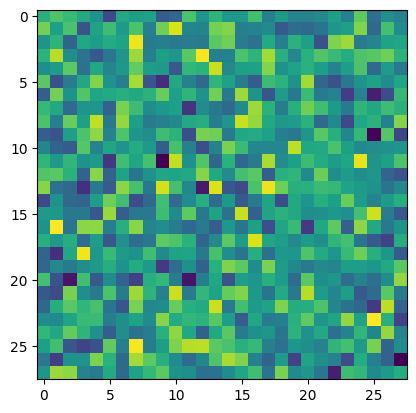

In [20]:
import matplotlib.pyplot as plt
img = data[1]
plt.imshow(img)

In [28]:
train_images, train_labels, test_images, test_labels = data[:60_000], labels[:60_000], data[60_000:], labels[60_000:]

In [29]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [30]:
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255
train_labels = train_labels.astype('uint8')
test_labels = test_labels.astype('uint8')

In [32]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1012 - loss: 2.3028
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1106 - loss: 2.3001
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1324 - loss: 2.2913
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1467 - loss: 2.2763
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1576 - loss: 2.2610


In [33]:
test_imgs = test_images[0:10]
predications = model.predict(test_imgs)
predications[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


array([0.11439614, 0.110286  , 0.10358493, 0.07468771, 0.08623846,
       0.08834334, 0.11803643, 0.12570177, 0.07630476, 0.10242039],
      dtype=float32)

In [ ]:
predications[0].argmax(), test_labels[0] # ❌ model make wrong predication

(np.int64(7), np.uint8(8))

In [37]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'test_acc {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0983 - loss: 2.3277
test_acc 0.09830000251531601
